In [10]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    prepare_operating_timeseries,
    compute_product_rate,
)

In [35]:
from pathlib import Path
from tsfresh.utilities.dataframe_functions import impute
import numpy as np


# --------------------------------------------------
# Load Data
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

rate_df = compute_product_rate(op_df, prod_df)

op_df_new = prepare_operating_timeseries(
    op_df,
    add_tier=False,
    resample_rule="1D"
)

op_df_new = op_df_new.reset_index()
op_df_new = op_df_new[op_df_new["Batch"] != 4053]
# op_df_new = op_df_new.drop(columns=["productivity_rank"])

op_df_new = op_df_new.replace([np.inf, -np.inf], np.nan)
op_df_new = op_df_new.fillna(0)

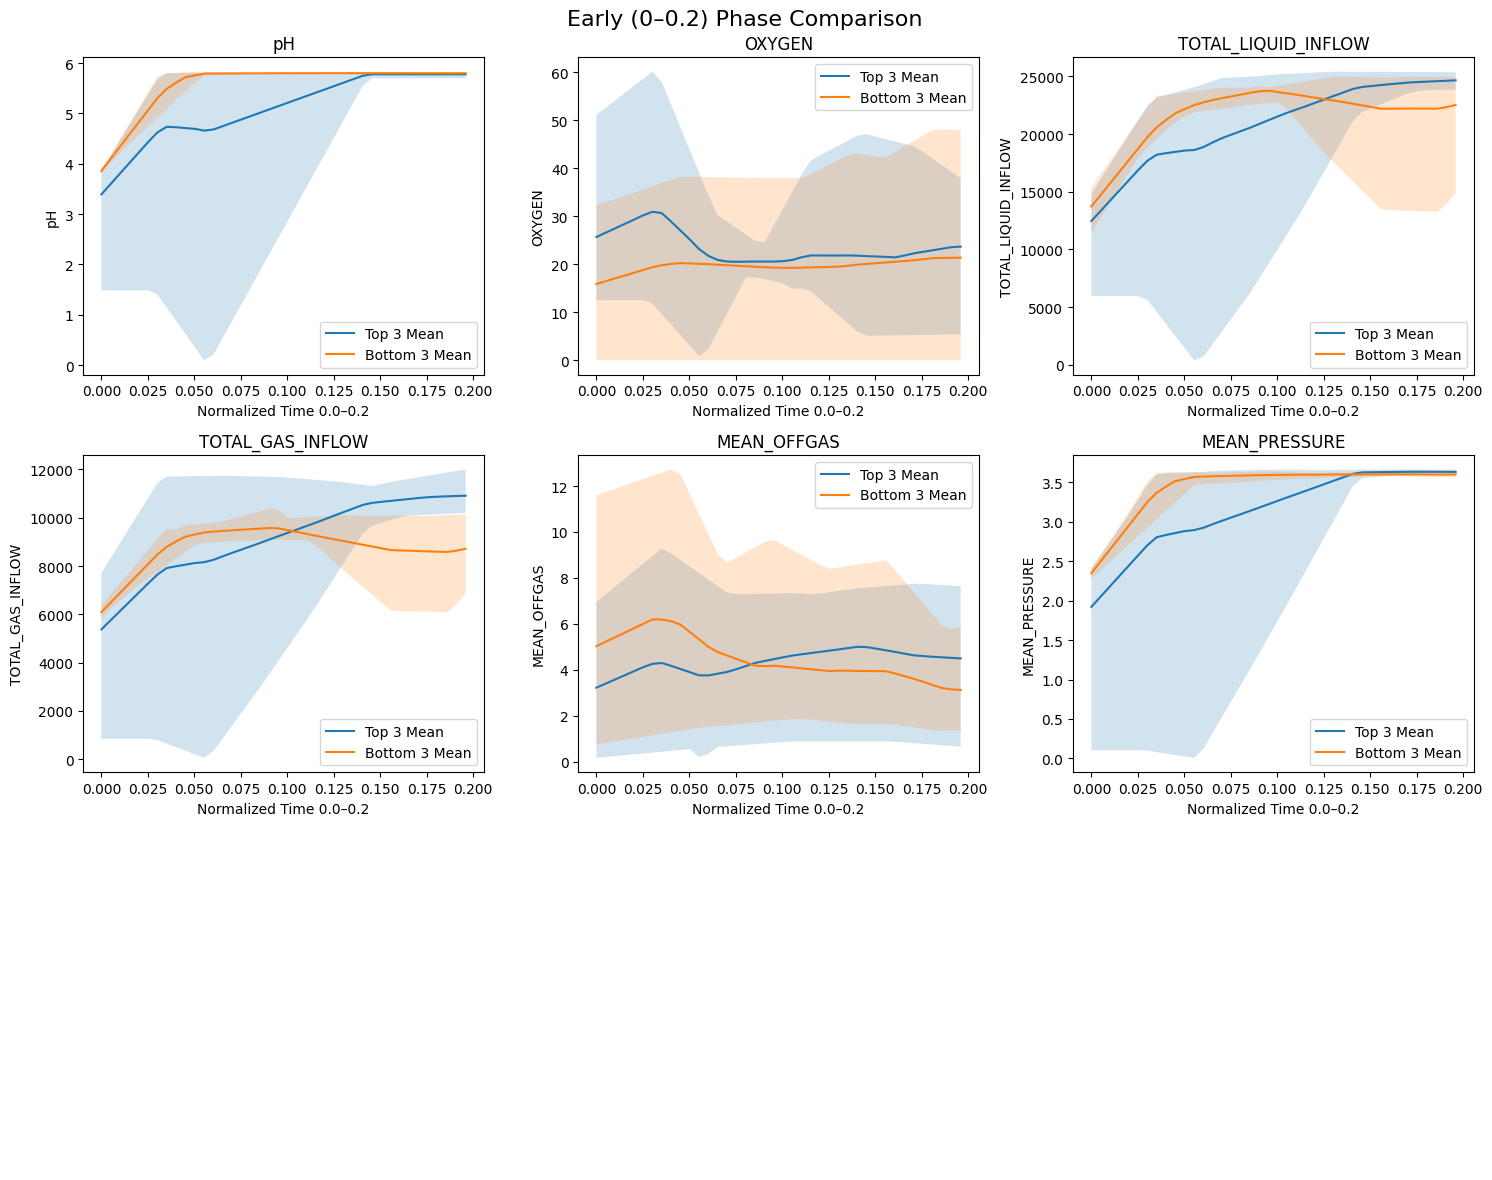

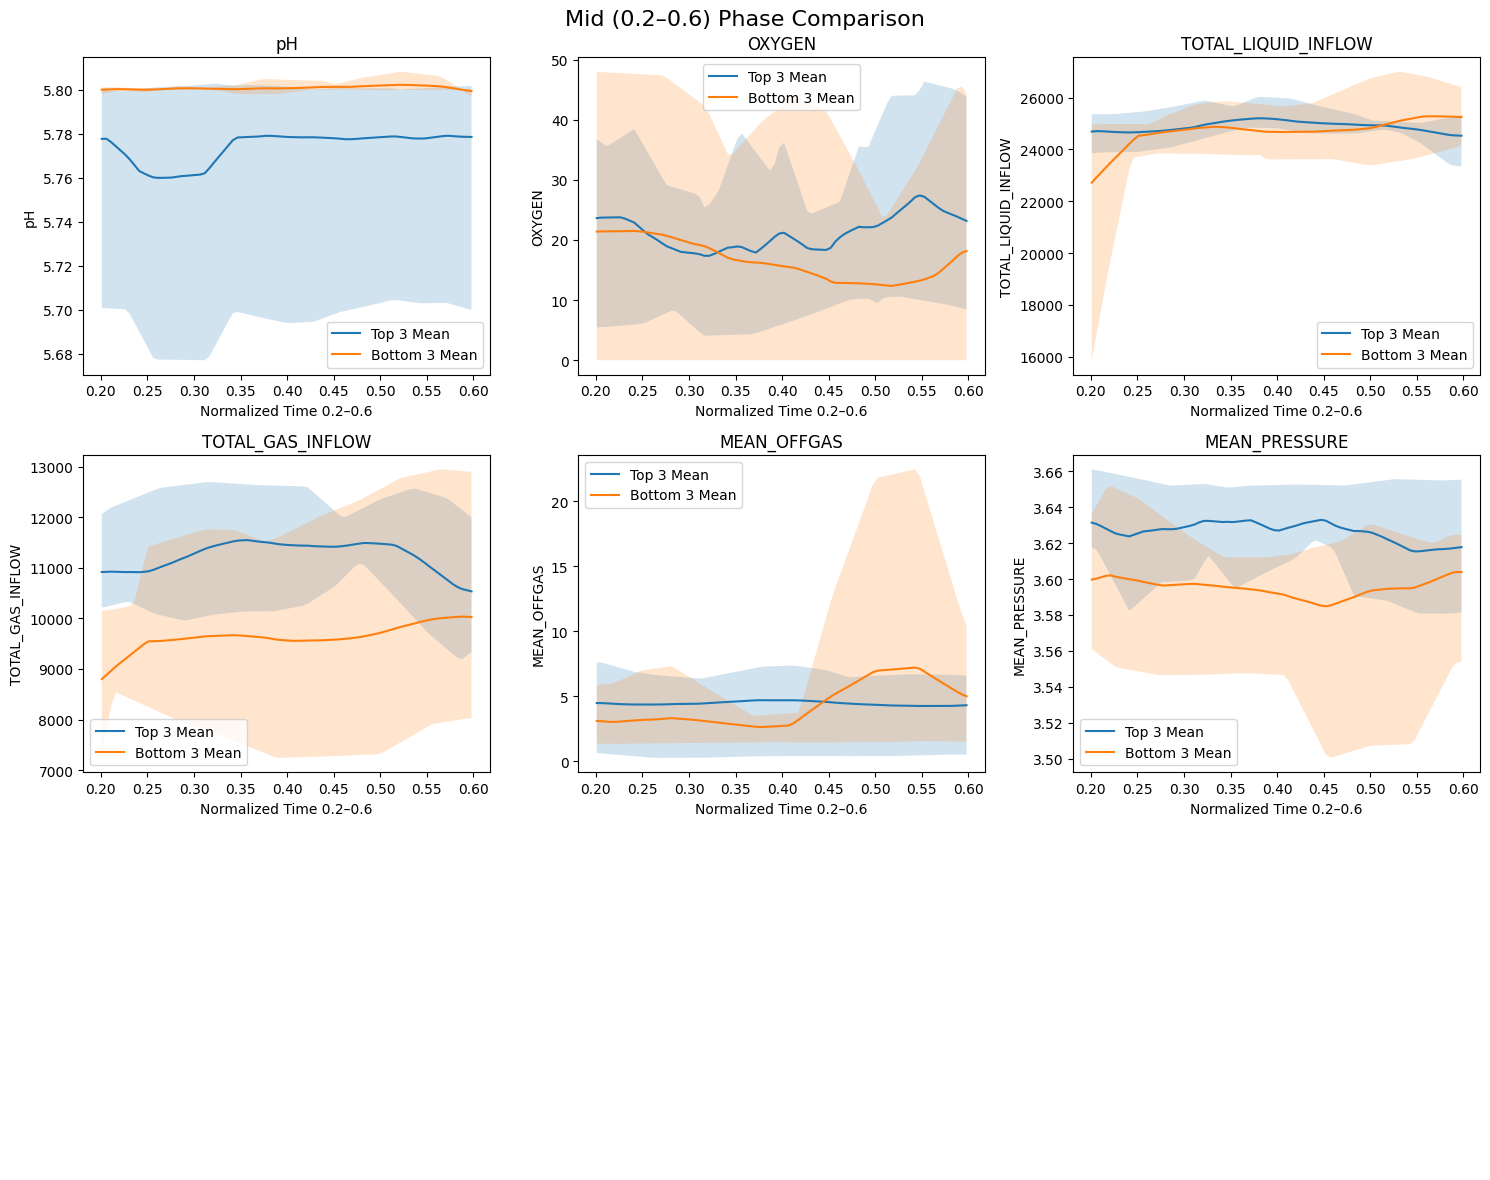

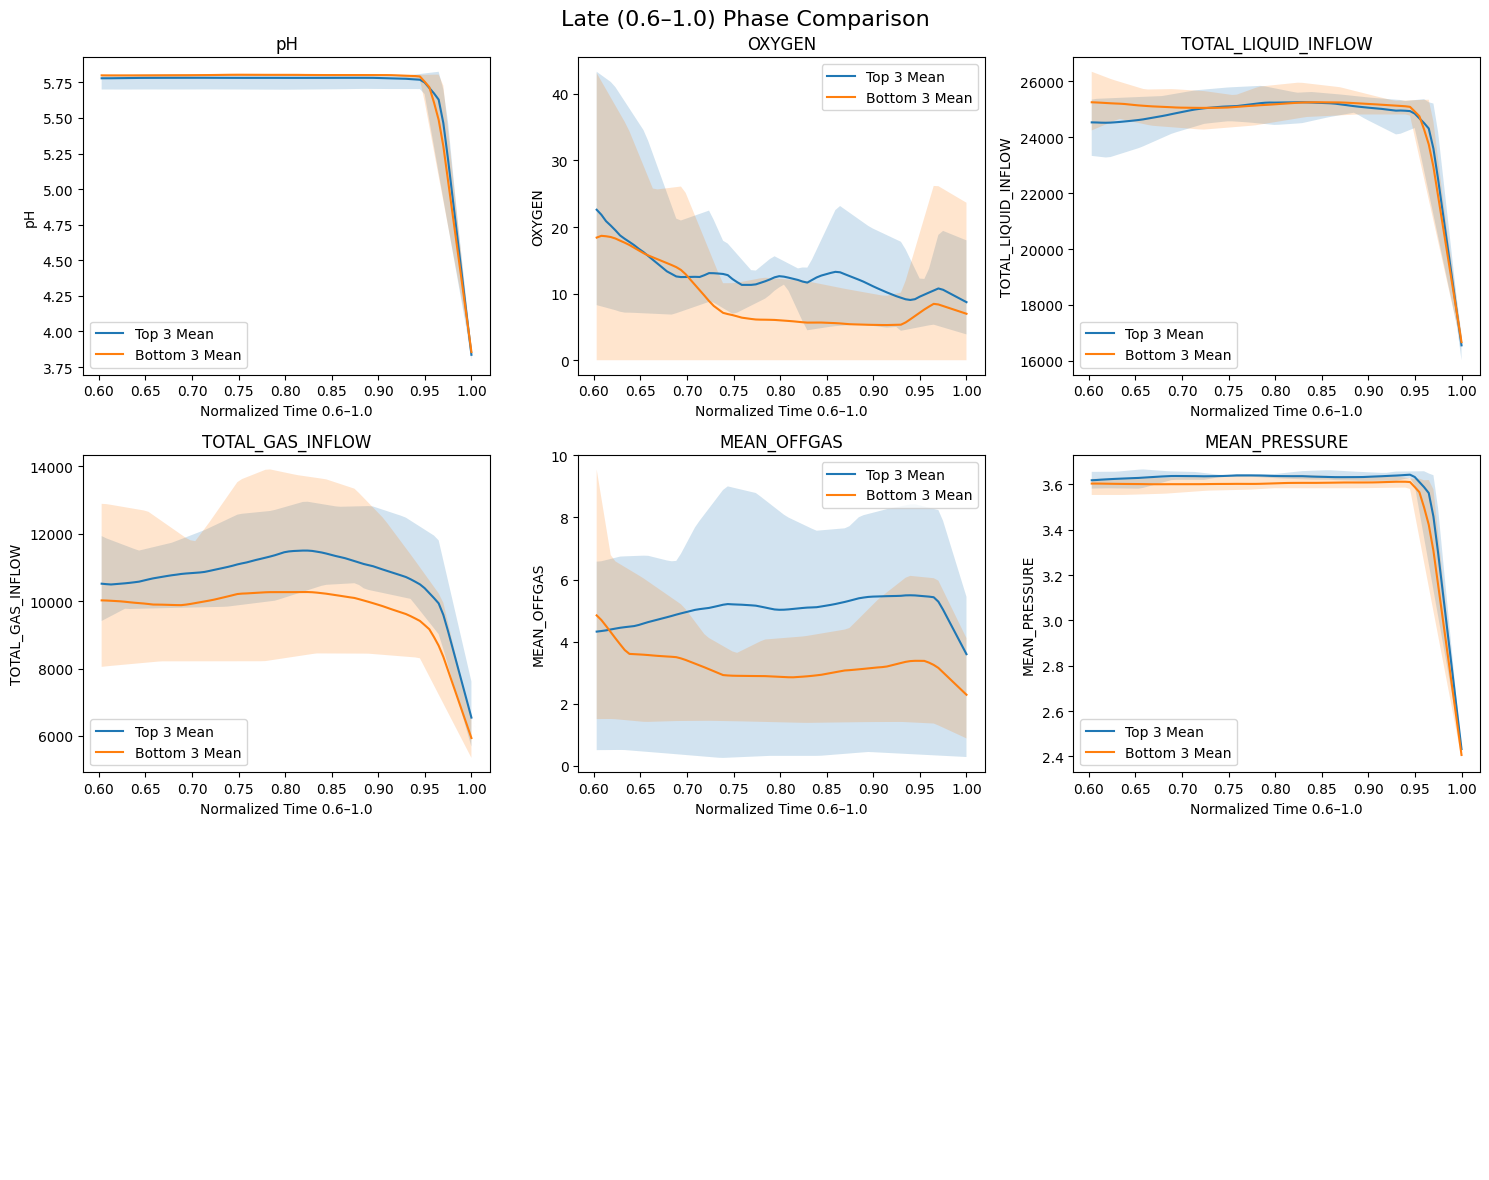

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(5)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(5)["Batch"]
    .values
)

# -------------------------
# Variables to plot
# -------------------------
variables = [
    "pH",
    "OXYGEN",
    "TOTAL_LIQUID_INFLOW",
    "TOTAL_GAS_INFLOW",
    "MEAN_OFFGAS",
    "MEAN_PRESSURE",
]

# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200, smooth_frac=0.05):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    x = np.linspace(0.0, 1.0, len(batch_df))
    y = batch_df[variable].astype(float).to_numpy()

    w = max(3, int(smooth_frac * len(batch_df)))
    y_smooth = np.convolve(y, np.ones(w) / w, mode="same")

    common_time = np.linspace(0.0, 1.0, n_points)
    interp_values = np.interp(common_time, x, y_smooth)

    return common_time, interp_values


# -------------------------
# Phase definitions
# -------------------------
phases = {
    "Early (0–0.2)": (0.0, 0.2),
    "Mid (0.2–0.6)": (0.2, 0.6),
    "Late (0.6–1.0)": (0.6, 1.0),
}

n_points = 200
common_time = np.linspace(0.0, 1.0, n_points)

# -------------------------
# Generate one 3x3 plot per phase
# -------------------------
for phase_name, (start, end) in phases.items():

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    mask = (common_time >= start) & (common_time <= end)
    time_plot = common_time[mask]

    for i, variable in enumerate(variables):

        top_curves = []
        bottom_curves = []

        for batch in top_batches:
            _, vals = get_normalized_variable(op_df_new, batch, variable, n_points=n_points)
            top_curves.append(vals)

        for batch in bottom_batches:
            _, vals = get_normalized_variable(op_df_new, batch, variable, n_points=n_points)
            bottom_curves.append(vals)

        top_arr = np.array(top_curves)
        bot_arr = np.array(bottom_curves)

        top_mean = top_arr.mean(axis=0)
        bot_mean = bot_arr.mean(axis=0)

        top_low, top_high = top_arr.min(axis=0), top_arr.max(axis=0)
        bot_low, bot_high = bot_arr.min(axis=0), bot_arr.max(axis=0)

        ax = axes[i]

        ax.plot(time_plot, top_mean[mask], label="Top 3 Mean")
        ax.fill_between(time_plot, top_low[mask], top_high[mask], alpha=0.2)

        ax.plot(time_plot, bot_mean[mask], label="Bottom 3 Mean")
        ax.fill_between(time_plot, bot_low[mask], bot_high[mask], alpha=0.2)

        ax.set_title(variable)
        ax.set_xlabel(f"Normalized Time {start:.1f}–{end:.1f}")
        ax.set_ylabel(variable)
        ax.legend()

    # Hide unused subplots
    for j in range(len(variables), 9):
        axes[j].axis("off")

    fig.suptitle(f"{phase_name} Phase Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

In [45]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# -------------------------
# Feature Extraction
# -------------------------

def extract_phase_features(df, n_points=200):

    feature_rows = []

    for batch_id, batch_df in df.groupby("Batch"):

        batch_df = batch_df.sort_values("Date and time")

        # Normalized time
        t = np.linspace(0.0, 1.0, len(batch_df))

        oxygen = batch_df["OXYGEN"].astype(float).values
        gas = batch_df["TOTAL_GAS_INFLOW"].astype(float).values
        liquid = batch_df["TOTAL_LIQUID_INFLOW"].astype(float).values

        # Early phase mask (0–0.2)
        early_mask = t <= 0.2

        # ----- EARLY GAS FEATURES -----
        early_gas_mean = gas[early_mask].mean()
        early_gas_integral = np.trapezoid(gas[early_mask], t[early_mask])
        early_gas_slope = linregress(t[early_mask], gas[early_mask]).slope

        # ----- EARLY OXYGEN FEATURES -----
        early_oxy_mean = oxygen[early_mask].mean()
        early_oxy_integral = np.trapezoid(oxygen[early_mask], t[early_mask])
        early_oxy_slope = linregress(t[early_mask], oxygen[early_mask]).slope
        early_oxy_drop = oxygen[0] - oxygen[early_mask].min()

        # Optional liquid
        early_liq_mean = liquid[early_mask].mean()

        feature_rows.append({
            "Batch": batch_id,
            "early_gas_mean": early_gas_mean,
            "early_gas_integral": early_gas_integral,
            "early_gas_slope": early_gas_slope,
            "early_oxy_mean": early_oxy_mean,
            "early_oxy_integral": early_oxy_integral,
            "early_oxy_slope": early_oxy_slope,
            "early_oxy_drop": early_oxy_drop,
            "early_liq_mean": early_liq_mean,
        })

    return pd.DataFrame(feature_rows)


features_df = extract_phase_features(op_df_new)

In [46]:
features_df

,Batch,early_gas_mean,early_gas_integral,early_gas_slope,early_oxy_mean,early_oxy_integral,early_oxy_slope,early_oxy_drop,early_liq_mean
0,4030,112.746767,21.621801,132.409028,20.588332,3.386805,-24.691626,21.190509,24497.491038
1,4032,10359.909127,1950.763598,14699.654890,26.017883,4.704921,-289.760394,45.043205,23448.410896
2,4033,9413.862085,1696.064757,-1498.549713,26.682353,4.153993,-36.744981,46.265058,23251.612905
3,4034,8541.456845,1612.311678,-13941.489167,20.785729,3.576219,110.246786,23.787604,24108.842819
4,4035,9197.285802,1705.338650,763.250384,11.149941,2.032814,-42.301687,8.124646,22489.498149
5,4036,9912.929956,1863.234702,4387.533794,28.261168,4.864534,110.136365,24.560574,24169.379717
6,4037,8956.236254,1637.135637,595.362533,42.116375,7.375339,-9.684583,31.949687,22303.141254
7,4038,9324.434691,1611.931563,-3115.555521,36.260048,6.128730,85.587657,11.219139,23798.185734
8,4039,9111.701431,1519.392083,-1172.652529,0.000000,0.000000,0.000000,0.000000,23230.272886
9,4040,9632.780603,1669.066734,7463.179880,21.520925,3.396313,73.082727,7.785238,23643.312757


In [47]:
rate_df

,Batch,product_rate
0,4030,616.305179
1,4032,621.162886
2,4033,608.869223
3,4034,622.196071
4,4035,606.416985
5,4036,609.172327
6,4037,568.419365
7,4038,593.373544
8,4039,581.763278
9,4040,651.303020


In [49]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# -------------------------
# Merge
# -------------------------
df = features_df.merge(rate_df, on="Batch", how="inner")

feature_cols = [c for c in df.columns if c not in ["Batch", "product_rate"]]

# Detect oxygen-missing batches (all oxy-derived features == 0)
oxy_cols = [c for c in feature_cols if "oxy" in c.lower()]
all_oxy_zero = (df[oxy_cols].abs().sum(axis=1) == 0)

print("Batches with all oxygen features == 0:", df.loc[all_oxy_zero, "Batch"].tolist())

# Drop them (for oxygen-dynamics analysis)
df_model = df.loc[~all_oxy_zero].copy()

X = df_model[feature_cols].astype(float)          # <-- DataFrame (keeps feature names)
y = df_model["product_rate"].astype(float)        # <-- Series

loo = LeaveOneOut()

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 200)))
])

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, max_iter=20000, random_state=0))
])

def loocv_predictions_df(estimator, X_df, y_ser):
    preds = np.zeros(len(y_ser), dtype=float)
    for train_idx, test_idx in loo.split(X_df):
        X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
        y_train = y_ser.iloc[train_idx]
        estimator.fit(X_train, y_train)
        preds[test_idx] = estimator.predict(X_test)
    return preds

ridge_preds = loocv_predictions_df(ridge, X, y)
lasso_preds = loocv_predictions_df(lasso, X, y)

print("\n--- LOBO CV Performance ---")
print(f"Ridge  R2: {r2_score(y, ridge_preds):.3f} | MAE: {mean_absolute_error(y, ridge_preds):.3f}")
print(f"Lasso  R2: {r2_score(y, lasso_preds):.3f} | MAE: {mean_absolute_error(y, lasso_preds):.3f}")

# Fit full for interpretation
ridge.fit(X, y)
lasso.fit(X, y)

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "ridge_coef": ridge.named_steps["model"].coef_,
    "lasso_coef": lasso.named_steps["model"].coef_,
}).sort_values("ridge_coef", key=lambda s: np.abs(s), ascending=False)

print("\n--- Coefficients (sorted by |ridge_coef|) ---")
print(coef_table.to_string(index=False))

print("\n--- Lasso selected features (non-zero) ---")
print(coef_table.loc[coef_table["lasso_coef"].abs() > 1e-8, ["feature", "lasso_coef"]].to_string(index=False))

# Permutation importance (no warnings now)
perm = permutation_importance(
    ridge, X, y,
    scoring="r2", n_repeats=200, random_state=0
)

perm_table = pd.DataFrame({
    "feature": feature_cols,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("\n--- Permutation importance (R2 drop) ---")
print(perm_table.to_string(index=False))

Batches with all oxygen features == 0: [4039]

--- LOBO CV Performance ---
Ridge  R2: 0.088 | MAE: 27.607
Lasso  R2: 0.093 | MAE: 26.949

--- Coefficients (sorted by |ridge_coef|) ---
           feature  ridge_coef  lasso_coef
   early_gas_slope   18.333204   19.790977
    early_oxy_drop   15.182896   24.513397
early_gas_integral  -12.449917  -37.658281
    early_gas_mean   10.977919   36.016739
    early_liq_mean    9.210701   12.345771
early_oxy_integral   -8.704538  -11.700520
   early_oxy_slope   -3.454687    3.149609
    early_oxy_mean    3.123493    0.000000

--- Lasso selected features (non-zero) ---
           feature  lasso_coef
   early_gas_slope   19.790977
    early_oxy_drop   24.513397
early_gas_integral  -37.658281
    early_gas_mean   36.016739
    early_liq_mean   12.345771
early_oxy_integral  -11.700520
   early_oxy_slope    3.149609

--- Permutation importance (R2 drop) ---
           feature  perm_importance_mean  perm_importance_std
   early_gas_slope              0

In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# -------------------------
# Merge
# -------------------------
df = features_df.merge(rate_df, on="Batch", how="inner")

# Detect oxygen-missing batches (all oxy-derived features == 0)
all_feature_cols = [c for c in df.columns if c not in ["Batch", "product_rate"]]
oxy_cols = [c for c in all_feature_cols if "oxy" in c.lower()]
all_oxy_zero = (df[oxy_cols].abs().sum(axis=1) == 0)

print("Batches with all oxygen features == 0:", df.loc[all_oxy_zero, "Batch"].tolist())

# Drop them (for oxygen-dynamics analysis)
df_model = df.loc[~all_oxy_zero].copy()

# -------------------------
# Pick "strong" features
# (edit this list if you want)
# -------------------------
strong_features = [
    "early_gas_slope",
    "early_oxy_drop",
    "early_gas_integral",
    "early_gas_mean",
    "early_liq_mean",
    "early_oxy_integral",
]

# Keep only features that actually exist in df_model
strong_features = [c for c in strong_features if c in df_model.columns]
if len(strong_features) == 0:
    raise ValueError("None of the strong_features are present in df_model columns.")

X = df_model[strong_features].astype(float)
y = df_model["product_rate"].astype(float)

loo = LeaveOneOut()

# -------------------------
# LOOCV helper
# -------------------------
def loocv_predictions(estimator, X_df, y_ser):
    preds = np.zeros(len(y_ser), dtype=float)
    for train_idx, test_idx in loo.split(X_df):
        X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
        y_train = y_ser.iloc[train_idx]
        estimator.fit(X_train, y_train)
        preds[test_idx] = estimator.predict(X_test)
    return preds

def evaluate_model(name, est, X, y):
    preds = loocv_predictions(est, X, y)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:<20} R2: {r2:>6.3f} | MAE: {mae:>7.3f}")
    return preds, r2, mae

# -------------------------
# Models
# -------------------------
models = {}

# Ridge (linear)
models["RidgeCV"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 200)))
])

# Lasso (linear sparse)
models["LassoCV"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, max_iter=50000, random_state=0))
])

# PLS Regression (linear, good for correlated sensors)
# NOTE: choose n_components carefully (<= n_features)
max_comp = min(len(strong_features), 6)
models["PLS(1)"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", PLSRegression(n_components=1))
])
if max_comp >= 2:
    models["PLS(2)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=2))
    ])
if max_comp >= 3:
    models["PLS(3)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=3))
    ])

# Random Forest (nonlinear)
models["RandomForest"] = RandomForestRegressor(
    n_estimators=2000,
    random_state=0,
    min_samples_leaf=2,
    max_features="sqrt"
)

# Gradient Boosting (nonlinear, often strong on tabular)
models["GradBoost"] = GradientBoostingRegressor(
    random_state=0,
    n_estimators=800,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.9
)

# -------------------------
# Evaluate
# -------------------------
print("\n--- LOOCV performance using strong features ---")
results = []
pred_store = {}

for name, est in models.items():
    preds, r2, mae = evaluate_model(name, est, X, y)
    results.append((name, r2, mae))
    pred_store[name] = preds

results_df = pd.DataFrame(results, columns=["model", "loocv_r2", "loocv_mae"]).sort_values("loocv_r2", ascending=False)
print("\n--- Summary ---")
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]["model"]
best_est = models[best_name]

print(f"\nBest by LOOCV R2: {best_name}")

# -------------------------
# Fit best model on full data + feature importance
# -------------------------
best_est.fit(X, y)

print("\n--- Feature importance / interpretation (best model) ---")

# Linear model coefficients
if isinstance(best_est, Pipeline) and hasattr(best_est.named_steps.get("model", None), "coef_"):
    model = best_est.named_steps["model"]
    # coef_ shape depends on model
    coef = model.coef_.ravel() if hasattr(model.coef_, "ravel") else np.array(model.coef_)
    coef_df = pd.DataFrame({"feature": strong_features, "coef": coef})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)
    print("\nCoefficients (sorted by |coef|):")
    print(coef_df[["feature", "coef"]].to_string(index=False))

# RF / GB feature_importances_
elif hasattr(best_est, "feature_importances_"):
    imp = best_est.feature_importances_
    imp_df = pd.DataFrame({"feature": strong_features, "importance": imp}).sort_values("importance", ascending=False)
    print("\nTree importance (Gini gain proxy):")
    print(imp_df.to_string(index=False))

# Always do permutation importance for comparability
print("\nPermutation importance on best model (R2 drop):")
perm = permutation_importance(best_est, X, y, scoring="r2", n_repeats=500, random_state=0)
perm_df = pd.DataFrame({
    "feature": strong_features,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)
print(perm_df.to_string(index=False))

# -------------------------
# Optional: show predictions vs actual for best model
# -------------------------
best_preds = pred_store[best_name]
pred_df = pd.DataFrame({
    "Batch": df_model["Batch"].values,
    "y_true": y.values,
    "y_pred_loocv": best_preds
}).sort_values("y_true", ascending=False)

print("\n--- LOOCV predictions (best model) ---")
print(pred_df.to_string(index=False))

Batches with all oxygen features == 0: [4039]

--- LOOCV performance using strong features ---
RidgeCV              R2:  0.275 | MAE:  24.254
LassoCV              R2:  0.107 | MAE:  25.740
PLS(1)               R2: -0.070 | MAE:  30.497
PLS(2)               R2:  0.079 | MAE:  28.706
PLS(3)               R2: -0.070 | MAE:  30.304
RandomForest         R2:  0.064 | MAE:  29.238
GradBoost            R2: -0.156 | MAE:  31.732

--- Summary ---
       model  loocv_r2  loocv_mae
     RidgeCV  0.274654  24.253606
     LassoCV  0.106854  25.740254
      PLS(2)  0.079018  28.705650
RandomForest  0.064102  29.237988
      PLS(1) -0.069806  30.497134
      PLS(3) -0.069889  30.303677
   GradBoost -0.155595  31.731902

Best by LOOCV R2: RidgeCV

--- Feature importance / interpretation (best model) ---

Coefficients (sorted by |coef|):
           feature       coef
early_gas_integral -22.411763
    early_gas_mean  20.880030
    early_oxy_drop  19.943466
   early_gas_slope  19.234364
    early_liq_mean

In [14]:
def pressure_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["MEAN_PRESSURE"].values

    return {
        "pressure_mean_early": np.mean(p),
        "pressure_min_early": np.min(p),
        "pressure_std_early": np.std(p),
        "pressure_drop_duration": np.sum(p < 3.2),  # threshold based on plot
        "pressure_drop_flag": int(np.min(p) < 3.0)
    }

def gas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    g = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(g))

    return {
        "gas_mean_early": np.mean(g),
        "gas_slope_early": np.polyfit(t, g, 1)[0],
        "gas_min_early": np.min(g),
        "gas_drop_flag": int(np.min(g) < 8000)
    }


def offgas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    o = early["MEAN_OFFGAS"].values

    return {
        "offgas_mean_early": np.mean(o),
        "offgas_std_early": np.std(o),
        "offgas_peak_early": np.max(o)
    }


def ph_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["pH"].values

    return {
        "pH_min_early": np.min(p),
        "pH_drop_flag": int(np.min(p) < 5.0)
    }

In [16]:
import pandas as pd

all_features = []

for batch in op_df_new["Batch"].unique():
    f = {}
    f.update(pressure_features(op_df_new, batch))
    f.update(gas_features(op_df_new, batch))
    f.update(offgas_features(op_df_new, batch))
    f.update(ph_features(op_df_new, batch))
    f["Batch"] = batch
    all_features.append(f)

features_df = pd.DataFrame(all_features)

In [18]:
features_df

,pressure_mean_early,pressure_min_early,pressure_std_early,pressure_drop_duration,pressure_drop_flag,gas_mean_early,gas_slope_early,gas_min_early,gas_drop_flag,offgas_mean_early,offgas_std_early,offgas_peak_early,pH_min_early,pH_drop_flag,Batch
0,3.631059,0.0000,0.201492,3,1,10872.326943,4.342951,0.000000,1,7.001889,2.738776,33.732500,0.000000,1,4041
1,3.644207,3.4000,0.029227,0,0,11857.349042,6.128647,5380.905000,1,0.499818,1.158605,10.837500,5.375000,0,4043
2,3.616093,3.4000,0.033777,0,0,10788.798325,-1.726155,6076.530000,1,3.121452,1.518057,16.402500,5.565000,0,4047
3,3.619550,3.1150,0.068220,4,0,10621.260806,3.972423,7877.800000,1,6.796807,1.544607,13.630000,3.205000,1,4040
4,2.671357,0.0000,1.594900,227,1,8032.967830,15.471019,0.000000,1,4.235148,2.834284,16.762500,0.000000,1,4042
5,3.625958,3.3950,0.029078,0,0,10428.068872,1.198697,8604.910000,0,7.162875,2.267102,19.822500,4.945000,1,4046
6,3.639962,3.3650,0.034995,0,0,11215.345437,7.854475,8576.850000,0,3.941935,3.830129,22.897500,6.510000,0,4045
7,3.588696,3.3500,0.080291,0,0,11348.538644,2.978685,7626.454000,1,1.950443,1.345192,15.311667,5.530000,0,4052
8,3.595892,3.3075,0.059205,0,0,9026.399807,2.242287,4596.130000,1,4.486441,1.175368,22.345000,5.530000,0,4034
9,3.644811,3.3650,0.041093,0,0,9758.117779,2.036422,8651.320000,0,2.505967,4.662484,43.175000,5.635000,0,4044


In [19]:
rate_df

,Batch,product_rate
0,4030,616.305179
1,4032,621.162886
2,4033,608.869223
3,4034,622.196071
4,4035,606.416985
5,4036,609.172327
6,4037,568.419365
7,4038,593.373544
8,4039,581.763278
9,4040,651.303020


In [21]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# Merge
# -----------------------------
df = features_df.merge(rate_df, on="Batch", how="inner").copy()

X = df.drop(columns=["Batch", "product_rate"])
y = df["product_rate"]

# Clean
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# -----------------------------
# Compute Pearson for each feature
# -----------------------------
results = []

for col in X.columns:
    r, p = pearsonr(X[col], y)
    
    results.append({
        "feature": col,
        "pearson_r": r,
        "p_value": p,
        "abs_r": abs(r)
    })

corr_df = pd.DataFrame(results).sort_values("abs_r", ascending=False)

print(corr_df)

                   feature  pearson_r   p_value     abs_r
10        offgas_std_early  -0.491847  0.023532  0.491847
11       offgas_peak_early  -0.458771  0.036453  0.458771
5           gas_mean_early   0.270217  0.236151  0.270217
6          gas_slope_early   0.196799  0.392534  0.196799
8            gas_drop_flag  -0.171553  0.457147  0.171553
9        offgas_mean_early   0.110651  0.633015  0.110651
13            pH_drop_flag   0.096874  0.676142  0.096874
2       pressure_std_early  -0.091391  0.693589  0.091391
7            gas_min_early   0.083580  0.718707  0.083580
1       pressure_min_early   0.069186  0.765707  0.069186
4       pressure_drop_flag  -0.062565  0.787610  0.062565
3   pressure_drop_duration   0.057008  0.806111  0.057008
12            pH_min_early   0.042949  0.853346  0.042949
0      pressure_mean_early   0.028154  0.903580  0.028154


In [22]:
X = df[["offgas_std_early", "offgas_peak_early"]]
y = df["product_rate"]

LOO RMSE: 36.98001096890533
LOO R2: -0.059728724054664895


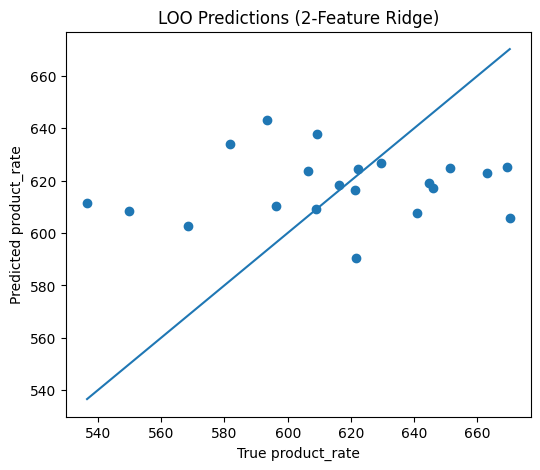


Coefficients:
             feature      coef
0   offgas_std_early -7.327797
1  offgas_peak_early -6.008644

Chosen alpha: 15.343684089300131


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1) X and y
# -----------------------------
X = df[["offgas_std_early", "offgas_peak_early"]].copy()
y = df["product_rate"].values

# -----------------------------
# 2) Model
# -----------------------------
alphas = np.logspace(-4, 4, 200)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

# -----------------------------
# 3) Leave-One-Out
# -----------------------------
loo = LeaveOneOut()
y_pred = cross_val_predict(model, X, y, cv=loo)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("LOO RMSE:", rmse)
print("LOO R2:", r2)

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("True product_rate")
plt.ylabel("Predicted product_rate")
plt.title("LOO Predictions (2-Feature Ridge)")
plt.show()

# -----------------------------
# 5) Fit on full data for interpretation
# -----------------------------
model.fit(X, y)

ridge = model.named_steps["ridge"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": ridge.coef_
}).sort_values("coef")

print("\nCoefficients:")
print(coef_df)

print("\nChosen alpha:", ridge.alpha_)

In [4]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_LIQUID_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_LIQUID_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_LIQUID_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [7]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_GAS_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_GAS_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_GAS_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_GAS_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [15]:
def early_gas_features(df, batch_id):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    early = batch_df[batch_df["time_norm"] <= 0.5]

    gas = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(gas))

    return {
        "Batch": batch_id,
        "gas_mean_early": np.mean(gas),
        "gas_std_early": np.std(gas),
        "gas_slope_early": np.polyfit(t, gas, 1)[0],
        "gas_auc_early": np.trapezoid(gas)
    }


import pandas as pd

# ---------------------------------------
# Compute early gas features for all batches
# ---------------------------------------
gas_feature_list = []

for batch_id in op_df_new["Batch"].unique():
    gas_feature_list.append(
        early_gas_features(op_df_new, batch_id)
    )

gas_features_df = pd.DataFrame(gas_feature_list)

# ---------------------------------------
# Align with productivity
# ---------------------------------------
prod_df = rate_df[["Batch", "product_rate"]]

gas_merged = gas_features_df.merge(prod_df, on="Batch")

from scipy.stats import spearmanr

results = []

for col in [
    "gas_mean_early",
    "gas_std_early",
    "gas_slope_early",
    "gas_auc_early"
]:
    corr, pval = spearmanr(
        gas_merged[col],
        gas_merged["product_rate"]
    )

    results.append({
        "feature": col,
        "spearman_corr": corr,
        "p_value": pval,
        "abs_corr": abs(corr)
    })

results_df = pd.DataFrame(results).sort_values(
    "abs_corr", ascending=False
)

results_df

,feature,spearman_corr,p_value,abs_corr
0,gas_mean_early,0.400000,0.072390,0.400000
3,gas_auc_early,0.335065,0.137610,0.335065
2,gas_slope_early,0.288312,0.205002,0.288312
1,gas_std_early,0.148052,0.521874,0.148052


In [ ]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [ ]:
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)

import numpy as np

def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    # Normalize time to 0–1
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    # Smooth OXYGEN
    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    # Interpolate onto fixed grid
    common_time = np.linspace(0, 1, n_points)
    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp

common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_mean = np.mean(top_curves, axis=0)
bottom_mean = np.mean(bottom_curves, axis=0)

import dearpygui.dearpygui as dpg

dpg.create_context()

with dpg.window(label="Mean OXYGEN Comparison", width=900, height=600):
    with dpg.plot(label="Top vs Bottom Mean OXYGEN", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–1)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        dpg.add_line_series(
            common_time.tolist(),
            top_mean.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            common_time.tolist(),
            bottom_mean.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Comparison", width=1000, height=700)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [1]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

NameError: name 'op_df_new' is not defined